# Unsupervised Wildlife Outlier Detection — v2.1
## Fast-motion detector and tracker

| Step | Does | Output |
|---|---|---|
| **0 — Calibration** | Learns pixels with persistent environmental motion | `tree_mask.npy` per clip |
| **1 — Detection & Tracking** | Stabilized frame difference + MOG2 + optical flow + velocity-aware Kalman tracking | SQLite `tracks` + `detections` |
| **2 — Feature Extraction** | DINOv2 embeddings + trajectory statistics | SQLite `embeddings` |
| **3 — Clustering** | UMAP + HDBSCAN, then anomaly ranking | Cluster labels + plots |

Step 1 is designed for objects that cross a frame in only a few frames. It uses optical-flow velocity to seed and associate tracks, so consecutive boxes do not need to overlap. The flow backend is selected at runtime: NVIDIA Optical Flow (NVOF), CUDA pyramidal LK, CPU pyramidal LK, or optional DIS dense flow.


In [1]:
# Standard CPU install (run once if needed):
# !pip install torch torchvision opencv-python-headless numpy scipy matplotlib tqdm umap-learn hdbscan

# Important: PyPI OpenCV wheels do not contain CUDA/NVOF. NVOF or CUDA LK requires a
# custom OpenCV + opencv_contrib build with CUDA/cudaoptflow enabled. The notebook
# detects that build automatically and safely falls back to CPU pyramidal LK.


In [ ]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from torchvision import transforms
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from dataclasses import dataclass, field
from typing import List, Optional, Tuple, Dict
import sqlite3, json, os, tempfile, warnings, time
from tqdm import tqdm

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


In [ ]:
# =============================================================================
# Configuration
# =============================================================================

# Paths
VIDEO_DIR  = Path("./footage")
OUTPUT_DIR = Path("./runs_v2")
DB_PATH    = OUTPUT_DIR / "tracks.db"
MASK_DIR   = OUTPUT_DIR / "tree_masks"
CROP_DIR   = OUTPUT_DIR / "crops"

for d in (OUTPUT_DIR, MASK_DIR, CROP_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Step 0: persistent environmental-motion calibration
CALIB_FRAMES         = 800
CALIB_FRAME_SKIP     = 1
CALIB_DIFF_THRESH    = 3 # was 5
CALIB_WINDOW_SIZE    = 10
STATIC_EXCL_FRACTION = 0.20
STATIC_EXCL_DILATE   = 30

# Step 1: processing. Keep PROCESS_EVERY_N=1 for five-frame crossings.
PROCESS_EVERY_N = 1
PROCESS_SCALE   = 0.75  # 0.75 is usually much faster while retaining small targets

# Flow backend: "auto", "nvof", "cuda_lk", "cpu_lk", or "dis".
# auto preference: NVOF -> CUDA pyramidal LK -> CPU pyramidal LK.
FLOW_BACKEND       = "auto"
NVOF_PERF_PRESET   = "FAST"
NVOF_GRID_SIZE     = 2
FLOW_MAX_CORNERS   = 1200
FLOW_QUALITY       = 0.008
FLOW_MIN_DISTANCE  = 5
LK_WIN_SIZE        = (41, 41)
LK_MAX_LEVEL       = 5
LK_MAX_ITERS       = 35
LK_MAX_ERROR       = 60.0
FLOW_MIN_MAG       = 1.25   # residual px needed to support a moving object
FLOW_FAST_MAG      = 3.0    # residual px allowed through the static exclusion mask
FLOW_POINT_RADIUS  = 10
FLOW_SUPPORT_DILATE = 25
FLOW_MIN_SUPPORT_POINTS = 2

# Current-position motion segmentation
FRAMEDIFF_THRESH       = 5
FRAMEDIFF_BLUR         = (5, 5)
FRAMEDIFF_SIGMA        = 1.1
FRAMEDIFF_ADAPTIVE_MAD = 2.5
MOG2_HISTORY           = 250
MOG2_VAR_THRESHOLD     = 16
MOG2_LEARNING_RATE     = -1

# Blob filtering. MAX_BLOB_AREA_FRAC scales with the processed frame.
MORPH_OPEN_K      = 3
MORPH_CLOSE_K     = 5
MOTION_DILATE_K   = 3
MIN_BLOB_AREA     = 5
MAX_BLOB_AREA_FRAC = 0.10
ROI_CTX_SCALE     = 1.6

# Velocity-aware tracker. Gates are fractions of the full-frame diagonal.
MAX_AGE               = 5
MIN_HITS              = 1
TRACK_INIT_GATE_FRAC  = 0.38
TRACK_BASE_GATE_FRAC  = 0.035
TRACK_MAX_GATE_FRAC   = 0.48
TRACK_SPEED_GATE_MULT = 2.5
TRACK_FLOW_BLEND      = 0.45
TRACK_SIZE_WEIGHT     = 0.18
TRACK_VELOCITY_WEIGHT = 0.22
TRACK_IOU_BONUS       = 0.20

# Trajectory / DINO / clustering
TRAJ_MIN_LEN   = 2
TRAJ_SPEED_MUL = 3.0
DINO_MODEL     = "dinov2_vitl14"
DINO_SIZE      = 336
EMBED_DIM      = 1024
CROPS_PER_TRACK = 8
TRACK_CUTOUT_SIZE = 256
TRACK_CUTOUT_CONTEXT = 1.25  # 12.5% breathing room on each side of the long axis
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST    = 0.1
HDBSCAN_MIN_SIZE = 5
TOP_K_ANOMALIES  = 50

VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".m4v"}

NIGHT_LUMA_THRESHOLD = 45
NIGHT_FRAMEDIFF_THRESH = 4       # was 12
NIGHT_MOG2_VAR_THRESHOLD = 24    # was 40
NIGHT_MIN_BLOB_AREA = 12         # was 30
NIGHT_MIN_BLOB_SIDE = 2          # was 4
NIGHT_OPEN_KERNEL = 3            # was 5
NIGHT_MOG2_LEARNING_RATE = 0.002

MIN_HITS = 3        

In [ ]:
# ═══════════════════════════════════════════════════════════
#  Database  — SQLite, one file for the whole project
# ═══════════════════════════════════════════════════════════
#
#  clips      — one row per video file
#  tracks     — one row per Kalman track (all clips)
#  detections — one row per frame a track appears in
#  embeddings — DINOv2 embedding per track (added in Step 2)

def get_db(path: Path = DB_PATH) -> sqlite3.Connection:
    con = sqlite3.connect(str(path))
    con.row_factory = sqlite3.Row
    return con

def init_db(path: Path = DB_PATH):
    con = get_db(path)
    con.executescript("""
    CREATE TABLE IF NOT EXISTS clips (
        name          TEXT PRIMARY KEY,
        fps           REAL,
        width         INTEGER,
        height        INTEGER,
        total_frames  INTEGER,
        processed_at  TEXT
    );

    CREATE TABLE IF NOT EXISTS tracks (
        id              INTEGER PRIMARY KEY AUTOINCREMENT,
        clip_name       TEXT,
        track_id        INTEGER,
        start_frame     INTEGER,
        end_frame       INTEGER,
        duration_frames INTEGER,
        mean_speed      REAL,
        std_speed       REAL,
        max_speed       REAL,
        displacement    REAL,
        path_length     REAL,
        linearity       REAL,
        mean_x          REAL,
        mean_y          REAL,
        trajectory_json TEXT,
        embedding_ready INTEGER DEFAULT 0,
        cluster_label       INTEGER DEFAULT -2,
        anomaly_rank        REAL    DEFAULT 0,
        video_cluster_label INTEGER DEFAULT -2,
        video_anomaly_rank  REAL    DEFAULT 0,
        UNIQUE(clip_name, track_id)
    );

    CREATE TABLE IF NOT EXISTS detections (
        id        INTEGER PRIMARY KEY AUTOINCREMENT,
        clip_name TEXT,
        track_id  INTEGER,
        frame_idx INTEGER,
        x1 REAL, y1 REAL, x2 REAL, y2 REAL,
        speed REAL
    );

    CREATE TABLE IF NOT EXISTS embeddings (
        clip_name TEXT,
        track_id  INTEGER,
        embedding BLOB,         -- raw float32 bytes (EMBED_DIM × 4 bytes)
        n_crops   INTEGER,
        PRIMARY KEY (clip_name, track_id)
    );
    """)

    # Migrate databases created by earlier notebook versions. The existing
    # cluster_label/anomaly_rank columns remain the overall-dataset result.
    columns = {row['name'] for row in con.execute('PRAGMA table_info(tracks)')}
    if 'video_cluster_label' not in columns:
        con.execute(
            'ALTER TABLE tracks ADD COLUMN video_cluster_label INTEGER DEFAULT -2')
    if 'video_anomaly_rank' not in columns:
        con.execute(
            'ALTER TABLE tracks ADD COLUMN video_anomaly_rank REAL DEFAULT 0')
    con.commit()
    con.close()
    print(f"Database ready: {path}")

init_db()


Database ready: runs_v2\tracks.db


In [ ]:
# ═══════════════════════════════════════════════════════════
#  Step 0 — Static exclusion mask  (tree / grass filter)
# ═══════════════════════════════════════════════════════════
#
#  Samples the first CALIB_FRAMES frames of each clip (every
#  CALIB_FRAME_SKIP-th frame).  Builds a per-pixel heatmap of
#  how often each pixel triggers motion. Pixels that are ALWAYS
#  moving (trees, grass, bushes) are excluded permanently.
#
#  The mask is saved as  MASK_DIR/<clip_stem>_mask.npy
#  and reused on subsequent runs — delete the file to recalibrate.

from collections import deque

def build_tree_mask(video_path: Path, mask_path: Path) -> np.ndarray:
    if mask_path.exists():
        mask = np.load(str(mask_path))
        print(f"  Loaded existing mask: {mask_path.name}  "
              f"({mask.sum()} px excluded, {100*mask.mean():.1f}%)")
        return mask

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise IOError(f"Cannot open {video_path}")

    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    if PROCESS_SCALE != 1.0:
        w = int(w * PROCESS_SCALE)
        h = int(h * PROCESS_SCALE)

    heatmap  = np.zeros((h, w), dtype=np.float32)
    prev_gray = None
    n_sampled = 0
    frame_idx = 0

    pbar = tqdm(total=CALIB_FRAMES, desc=f"  Calibrating {video_path.name}", leave=False)

    while n_sampled < CALIB_FRAMES:
        ret, frame = cap.read()
        if not ret:
            break
        frame_idx += 1
        if frame_idx % CALIB_FRAME_SKIP != 0:
            continue
        if PROCESS_SCALE != 1.0:
            frame = cv2.resize(frame, (w, h))

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, FRAMEDIFF_BLUR, FRAMEDIFF_SIGMA)

        if prev_gray is not None:
            diff = cv2.absdiff(blur, prev_gray)
            motion = diff >= CALIB_DIFF_THRESH
            heatmap += motion.astype(np.float32)
            n_sampled += 1
            pbar.update(1)

        prev_gray = blur   # store blurred version for next diff

    pbar.close()
    cap.release()

    if n_sampled == 0:
        return np.zeros((h, w), dtype=bool)

    fraction = heatmap / n_sampled
    mask = fraction > STATIC_EXCL_FRACTION

    if STATIC_EXCL_DILATE > 1:
        k = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE, (STATIC_EXCL_DILATE, STATIC_EXCL_DILATE))
        mask = cv2.dilate(mask.astype(np.uint8), k).astype(bool)

    np.save(str(mask_path), mask)
    pct = 100.0 * mask.mean()
    print(f"  Mask built: {mask.sum()} px excluded ({pct:.1f}%)  →  {mask_path.name}")
    return mask

def run_calibration():
    video_files = sorted(p for p in VIDEO_DIR.iterdir()
                         if p.suffix.lower() in VIDEO_EXTS)
    print(f"Step 0 — Calibrating tree masks for {len(video_files)} clip(s)\n")
    masks = {}
    for vp in video_files:
        mp = MASK_DIR / f"{vp.stem}_mask.npy"
        masks[vp.name] = build_tree_mask(vp, mp)
    print("\nCalibration complete.")
    return masks

TREE_MASKS = run_calibration()


Step 0 — Calibrating tree masks for 1 clip(s)

  Loaded existing mask: f_2020-03-16_03-42-13_c_mask.npy  (166525 px excluded, 5.9%)

Calibration complete.


In [ ]:
# ═══════════════════════════════════════════════════════════
#  DINOv2  (used in Step 2 only)
# ═══════════════════════════════════════════════════════════

def load_dino(model_name: str = DINO_MODEL):
    print(f"Loading {model_name} ...")
    model = torch.hub.load('facebookresearch/dinov2', model_name, verbose=False)
    model = model.half()       # FP16 — halves VRAM, no quality loss for inference
    model.eval().to(DEVICE)
    vram = torch.cuda.memory_allocated() / 1e9 if torch.cuda.is_available() else 0
    print(f"  Loaded. VRAM used: {vram:.2f} GB")
    return model

_DINO_TRANSFORM = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((DINO_SIZE, DINO_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def embed_crops(model, crops_bgr: List[np.ndarray]) -> torch.Tensor:
    """Embed BGR crops → L2-normalised (N, EMBED_DIM) float32 tensor."""
    if not crops_bgr:
        return torch.empty(0, EMBED_DIM)
    tensors = []
    for crop in crops_bgr:
        if crop is None or crop.size == 0 or crop.shape[0] < 4 or crop.shape[1] < 4:
            crop = np.zeros((DINO_SIZE, DINO_SIZE, 3), dtype=np.uint8)
        tensors.append(_DINO_TRANSFORM(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)))
    batch = torch.stack(tensors).half().to(DEVICE)
    embs  = model(batch).float()
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    del batch
    return F.normalize(embs.cpu(), dim=-1)

# Load lazily — only needed for Step 2
DINO = None
def get_dino():
    global DINO
    if DINO is None:
        DINO = load_dino()
    return DINO


In [ ]:
# =============================================================================
# Velocity-aware Kalman tracker
# =============================================================================

try:
    from scipy.optimize import linear_sum_assignment
except Exception:
    linear_sum_assignment = None


def _bbox_center_size(bbox):
    x1, y1, x2, y2 = np.asarray(bbox, dtype=np.float64)
    return np.array([(x1+x2)/2, (y1+y2)/2,
                     max(x2-x1, 2.0), max(y2-y1, 2.0)])


def _iou(b1, b2):
    xi1, yi1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    xi2, yi2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0.0, xi2-xi1) * max(0.0, yi2-yi1)
    a1 = max(0.0, b1[2]-b1[0]) * max(0.0, b1[3]-b1[1])
    a2 = max(0.0, b2[2]-b2[0]) * max(0.0, b2[3]-b2[1])
    return inter / (a1+a2-inter+1e-6)


class KalmanBoxTracker:
    """Constant-velocity [cx, cy, vx, vy, w, h] filter.

    Optical-flow velocity seeds a track on its first observation. This is the key
    difference from a plain SORT tracker, whose initial zero velocity cannot match
    an object that jumps hundreds of pixels before its second observation.
    """
    _next_id = 0

    def __init__(self, detection):
        KalmanBoxTracker._next_id += 1
        self.id = KalmanBoxTracker._next_id
        cx, cy, w, h = _bbox_center_size(detection["bbox"])
        velocity = np.asarray(detection.get("velocity", (0.0, 0.0)), dtype=np.float64)
        self.x = np.array([cx, cy, velocity[0], velocity[1], w, h], dtype=np.float64)
        self.P = np.diag([100.0, 100.0, 900.0, 900.0, 100.0, 100.0])
        self.H = np.zeros((4, 6), dtype=np.float64)
        self.H[0, 0] = self.H[1, 1] = self.H[2, 4] = self.H[3, 5] = 1.0
        self.R = np.diag([9.0, 9.0, 16.0, 16.0])
        self.hits = 1
        self.age = 0
        self.time_since_update = 0
        self.last_observed_bbox = np.asarray(detection["bbox"], dtype=np.float64)
        self.last_speed = float(np.linalg.norm(velocity))

    def _bbox(self):
        cx, cy, _, _, w, h = self.x
        w, h = max(w, 2.0), max(h, 2.0)
        return np.array([cx-w/2, cy-h/2, cx+w/2, cy+h/2])

    def predict(self, dt=1.0):
        F = np.eye(6, dtype=np.float64)
        F[0, 2] = F[1, 3] = dt
        speed = np.linalg.norm(self.x[2:4])
        pos_noise = 2.0 + 0.04 * speed * dt
        Q = np.diag([pos_noise**2, pos_noise**2, 16.0, 16.0, 4.0, 4.0])
        self.x = F @ self.x
        self.P = F @ self.P @ F.T + Q
        self.age += int(max(1, round(dt)))
        self.time_since_update += int(max(1, round(dt)))
        return self._bbox()

    def update(self, detection):
        z = _bbox_center_size(detection["bbox"])
        innovation = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x += K @ innovation
        self.P = (np.eye(6) - K @ self.H) @ self.P

        flow_v = np.asarray(detection.get("velocity", (np.nan, np.nan)), dtype=np.float64)
        if np.all(np.isfinite(flow_v)) and np.linalg.norm(flow_v) > 0:
            self.x[2:4] = ((1.0-TRACK_FLOW_BLEND) * self.x[2:4]
                           + TRACK_FLOW_BLEND * flow_v)
        self.hits += 1
        self.time_since_update = 0
        self.last_observed_bbox = np.asarray(detection["bbox"], dtype=np.float64)
        self.last_speed = float(np.linalg.norm(self.x[2:4]))

    def confirmed(self):
        return self.hits >= MIN_HITS


class Tracker:
    def __init__(self, frame_shape):
        h, w = frame_shape[:2]
        self.diagonal = float(np.hypot(w, h))
        self.tracks: List[KalmanBoxTracker] = []

    def _gate(self, track, dt):
        if track.hits <= 1:
            return TRACK_INIT_GATE_FRAC * self.diagonal
        dynamic = (TRACK_BASE_GATE_FRAC * self.diagonal
                   + TRACK_SPEED_GATE_MULT * np.linalg.norm(track.x[2:4]) * dt)
        return min(TRACK_MAX_GATE_FRAC * self.diagonal, dynamic)

    def _cost(self, track, predicted_bbox, detection, dt):
        pb = _bbox_center_size(predicted_bbox)
        db = _bbox_center_size(detection["bbox"])
        distance = np.linalg.norm(pb[:2] - db[:2])
        gate = self._gate(track, dt)
        if distance > gate:
            return np.inf

        size_penalty = abs(np.log((db[2]*db[3]+1.0)/(pb[2]*pb[3]+1.0)))
        velocity_penalty = 0.0
        dv = np.asarray(detection.get("velocity", (np.nan, np.nan)), dtype=np.float64)
        tv = track.x[2:4]
        if np.all(np.isfinite(dv)) and np.linalg.norm(dv) > 1 and np.linalg.norm(tv) > 1:
            cosine = np.dot(dv, tv) / (np.linalg.norm(dv)*np.linalg.norm(tv)+1e-6)
            velocity_penalty = 0.5 * (1.0 - np.clip(cosine, -1.0, 1.0))

        return (distance/gate
                + TRACK_SIZE_WEIGHT * min(size_penalty, 3.0)
                + TRACK_VELOCITY_WEIGHT * velocity_penalty
                - TRACK_IOU_BONUS * _iou(predicted_bbox, detection["bbox"]))

    def update(self, detections, dt=1.0):
        predicted = [t.predict(dt) for t in self.tracks]
        matches = []

        if self.tracks and detections:
            cost = np.full((len(self.tracks), len(detections)), np.inf, dtype=np.float64)
            for ti, (track, pb) in enumerate(zip(self.tracks, predicted)):
                for di, detection in enumerate(detections):
                    cost[ti, di] = self._cost(track, pb, detection, dt)

            if linear_sum_assignment is not None:
                safe = np.where(np.isfinite(cost), cost, 1e6)
                rows, cols = linear_sum_assignment(safe)
                matches = [(int(ti), int(di)) for ti, di in zip(rows, cols)
                           if np.isfinite(cost[ti, di])]
            else:
                work = cost.copy()
                for _ in range(min(work.shape)):
                    ti, di = np.unravel_index(np.argmin(work), work.shape)
                    if not np.isfinite(work[ti, di]):
                        break
                    matches.append((int(ti), int(di)))
                    work[ti, :] = np.inf
                    work[:, di] = np.inf

        for ti, di in matches:
            self.tracks[ti].update(detections[di])

        matched_d = {di for _, di in matches}
        new_track_indices = []
        for di, detection in enumerate(detections):
            if di not in matched_d:
                self.tracks.append(KalmanBoxTracker(detection))
                new_track_indices.append(len(self.tracks)-1)

        matched_t = {ti for ti, _ in matches} | set(new_track_indices)
        # Emit only tracks backed by a real detection in this frame. Predicted-only
        # boxes remain available for reassociation, but are never written as ghosts.
        observed = []
        for ti in sorted(matched_t):
            track = self.tracks[ti]
            if track.confirmed():
                observed.append({
                    "track_id": track.id,
                    "bbox": track.last_observed_bbox.tolist(),
                    "speed": track.last_speed,
                })

        self.tracks = [t for t in self.tracks if t.time_since_update <= MAX_AGE]
        return observed


In [ ]:
# =============================================================================
# Motion utilities and accelerated optical-flow backend selection
# =============================================================================

cv2.setUseOptimized(True)

_OPEN_KERNEL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                                          (MORPH_OPEN_K, MORPH_OPEN_K))
_CLOSE_KERNEL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                                           (MORPH_CLOSE_K, MORPH_CLOSE_K))
_DILATE_KERNEL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                                            (MOTION_DILATE_K, MOTION_DILATE_K))
_SUPPORT_KERNEL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                                             (FLOW_SUPPORT_DILATE, FLOW_SUPPORT_DILATE))


@dataclass
class FlowResult:
    global_shift: np.ndarray
    motion_mask: np.ndarray
    fast_mask: np.ndarray
    points: np.ndarray
    vectors: np.ndarray
    backend: str


def _empty_flow(shape, backend):
    return FlowResult(np.zeros(2, np.float32), np.zeros(shape, np.uint8),
                      np.zeros(shape, np.uint8),
                      np.empty((0, 2), np.float32),
                      np.empty((0, 2), np.float32), backend)


class MotionFlowEngine:
    """NVOF/CUDA-LK/CPU-LK adapter with automatic fail-safe fallback."""
    def __init__(self, shape):
        self.h, self.w = shape[:2]
        self.backend = None
        self.impl = None
        self._select_backend(FLOW_BACKEND.lower())

    @staticmethod
    def capability_report():
        cuda_devices = 0
        try:
            cuda_devices = cv2.cuda.getCudaEnabledDeviceCount()
        except Exception:
            pass
        return {
            "opencv": cv2.__version__,
            "cuda_devices": cuda_devices,
            "nvof2_binding": hasattr(cv2, "cuda_NvidiaOpticalFlow_2_0"),
            "cuda_lk_binding": hasattr(cv2, "cuda_SparsePyrLKOpticalFlow"),
            "dis_binding": hasattr(cv2, "DISOpticalFlow_create"),
        }

    def _select_backend(self, requested):
        caps = self.capability_report()
        order = ([requested] if requested != "auto"
                 else ["nvof", "cuda_lk", "cpu_lk"])
        errors = []
        for name in order:
            try:
                if name == "nvof" and caps["cuda_devices"] and caps["nvof2_binding"]:
                    cls = cv2.cuda_NvidiaOpticalFlow_2_0
                    perf = getattr(cls, f"NV_OF_PERF_LEVEL_{NVOF_PERF_PRESET}")
                    grid = getattr(cls, f"NV_OF_OUTPUT_VECTOR_GRID_SIZE_{NVOF_GRID_SIZE}")
                    hint = getattr(cls, "NV_OF_HINT_VECTOR_GRID_SIZE_1")
                    self.impl = cls.create((self.w, self.h), perf, grid, hint,
                                           True, False, False, 0)
                    self.backend = "nvof"
                    break
                if name == "cuda_lk" and caps["cuda_devices"] and caps["cuda_lk_binding"]:
                    self.impl = cv2.cuda_SparsePyrLKOpticalFlow.create(
                        LK_WIN_SIZE, LK_MAX_LEVEL, LK_MAX_ITERS, False)
                    self.backend = "cuda_lk"
                    break
                if name == "dis" and caps["dis_binding"]:
                    self.impl = cv2.DISOpticalFlow_create(cv2.DISOPTICAL_FLOW_PRESET_FAST)
                    self.impl.setUseSpatialPropagation(True)
                    self.backend = "dis"
                    break
                if name == "cpu_lk":
                    self.backend = "cpu_lk"
                    self.impl = None
                    break
            except Exception as exc:
                errors.append(f"{name}: {exc}")

        if self.backend is None:
            self.backend = "cpu_lk"
            self.impl = None
        suffix = f"; unavailable backends: {' | '.join(errors)}" if errors else ""
        print(f"  Optical flow backend: {self.backend}{suffix}")

    @staticmethod
    def _robust_global(flow):
        if len(flow) < 6:
            return np.zeros(2, np.float32)
        first = np.median(flow, axis=0)
        deviation = np.linalg.norm(flow-first, axis=1)
        mad = np.median(np.abs(deviation-np.median(deviation))) + 1e-6
        background = deviation <= max(1.5, np.median(deviation)+3.5*mad)
        return np.median(flow[background], axis=0).astype(np.float32)

    def _points_to_result(self, prev_pts, next_pts, flow, backend):
        global_shift = self._robust_global(flow)
        residual = flow - global_shift
        residual_mag = np.linalg.norm(residual, axis=1)
        moving = residual_mag >= FLOW_MIN_MAG
        endpoints = next_pts[moving].astype(np.float32)
        vectors = flow[moving].astype(np.float32)
        mask = np.zeros((self.h, self.w), np.uint8)
        fast_mask = np.zeros_like(mask)
        moving_residual = residual_mag[moving]
        for (x, y), magnitude in zip(np.rint(endpoints).astype(np.int32), moving_residual):
            if 0 <= x < self.w and 0 <= y < self.h:
                cv2.circle(mask, (x, y), FLOW_POINT_RADIUS, 255, -1)
                if magnitude >= FLOW_FAST_MAG:
                    cv2.circle(fast_mask, (x, y), FLOW_POINT_RADIUS, 255, -1)
        return FlowResult(global_shift, mask, fast_mask, endpoints, vectors, backend)

    def _analyze_sparse(self, prev, curr):
        pts = cv2.goodFeaturesToTrack(prev, maxCorners=FLOW_MAX_CORNERS,
                                      qualityLevel=FLOW_QUALITY,
                                      minDistance=FLOW_MIN_DISTANCE,
                                      blockSize=5)
        if pts is None or len(pts) < 4:
            return _empty_flow(prev.shape, self.backend)

        if self.backend == "cuda_lk":
            try:
                gp, gc, gpts = cv2.cuda_GpuMat(), cv2.cuda_GpuMat(), cv2.cuda_GpuMat()
                gp.upload(prev); gc.upload(curr)
                gpts.upload(pts.reshape(1, -1, 2).astype(np.float32))
                result = self.impl.calc(gp, gc, gpts, None)
                next_pts = result[0].download().reshape(-1, 2)
                status = result[1].download().reshape(-1).astype(bool)
                err = (result[2].download().reshape(-1) if len(result) > 2
                       and result[2] is not None else np.zeros(len(status)))
            except Exception as exc:
                print(f"  CUDA LK failed ({exc}); switching to CPU pyramidal LK")
                self.backend, self.impl = "cpu_lk", None
                return self._analyze_sparse(prev, curr)
        else:
            next_raw, status_raw, err_raw = cv2.calcOpticalFlowPyrLK(
                prev, curr, pts, None, winSize=LK_WIN_SIZE, maxLevel=LK_MAX_LEVEL,
                criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
                          LK_MAX_ITERS, 0.01),
                flags=0, minEigThreshold=1e-5)
            if next_raw is None:
                return _empty_flow(prev.shape, self.backend)
            next_pts = next_raw.reshape(-1, 2)
            status = status_raw.reshape(-1).astype(bool)
            err = err_raw.reshape(-1)

        prev_pts = pts.reshape(-1, 2)
        good = status & np.isfinite(next_pts).all(axis=1) & (err <= LK_MAX_ERROR)
        if good.sum() < 4:
            return _empty_flow(prev.shape, self.backend)
        prev_pts, next_pts = prev_pts[good], next_pts[good]
        return self._points_to_result(prev_pts, next_pts, next_pts-prev_pts, self.backend)

    def _dense_to_result(self, flow, backend):
        fh, fw = flow.shape[:2]
        flat = flow.reshape(-1, 2)
        global_shift = self._robust_global(flat[::max(1, len(flat)//12000)])
        residual_mag = np.linalg.norm(flow-global_shift, axis=2)
        moving_small = (residual_mag >= FLOW_MIN_MAG).astype(np.uint8) * 255
        fast_small = (residual_mag >= FLOW_FAST_MAG).astype(np.uint8) * 255
        mask = cv2.resize(moving_small, (self.w, self.h), interpolation=cv2.INTER_NEAREST)
        fast_mask = cv2.resize(fast_small, (self.w, self.h), interpolation=cv2.INTER_NEAREST)

        ys, xs = np.nonzero(moving_small)
        if len(xs) > 3000:
            keep = np.linspace(0, len(xs)-1, 3000, dtype=np.int32)
            xs, ys = xs[keep], ys[keep]
        vectors = flow[ys, xs].astype(np.float32) if len(xs) else np.empty((0,2), np.float32)
        sx, sy = self.w/fw, self.h/fh
        endpoints = (np.column_stack(((xs+0.5)*sx, (ys+0.5)*sy)).astype(np.float32)
                     + vectors) if len(xs) else np.empty((0,2), np.float32)
        return FlowResult(global_shift, mask, fast_mask, endpoints, vectors, backend)

    def _analyze_nvof(self, prev, curr):
        try:
            gp, gc = cv2.cuda_GpuMat(), cv2.cuda_GpuMat()
            gp.upload(prev); gc.upload(curr)
            raw = self.impl.calc(gp, gc, None)
            raw = raw[0] if isinstance(raw, tuple) else raw
            converted = self.impl.convertToFloat(raw, None)
            converted = converted[0] if isinstance(converted, tuple) else converted
            flow = converted.download() if hasattr(converted, "download") else converted
            return self._dense_to_result(np.asarray(flow, np.float32), "nvof")
        except Exception as exc:
            print(f"  NVOF failed ({exc}); switching to CPU pyramidal LK")
            try:
                self.impl.collectGarbage()
            except Exception:
                pass
            self.backend, self.impl = "cpu_lk", None
            return self._analyze_sparse(prev, curr)

    def analyze(self, prev, curr):
        if self.backend == "nvof":
            return self._analyze_nvof(prev, curr)
        if self.backend == "dis":
            try:
                return self._dense_to_result(self.impl.calc(prev, curr, None), "dis")
            except Exception as exc:
                print(f"  DIS flow failed ({exc}); switching to CPU pyramidal LK")
                self.backend, self.impl = "cpu_lk", None
        return self._analyze_sparse(prev, curr)


def blur_gray(frame, night=False):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if night:
        # Median filtering is particularly effective against nighttime speckles.
        gray = cv2.medianBlur(gray, 5)

    return cv2.GaussianBlur(
        gray,
        (7, 7) if night else FRAMEDIFF_BLUR,
        1.8 if night else FRAMEDIFF_SIGMA,
    )


def stabilized_difference(prev, curr, global_shift, night=False):
    dx, dy = float(global_shift[0]), float(global_shift[1])

    transform = np.array(
        [[1.0, 0.0, dx], [0.0, 1.0, dy]],
        dtype=np.float32,
    )

    aligned = cv2.warpAffine(
        prev,
        transform,
        (curr.shape[1], curr.shape[0]),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REPLICATE,
    )

    diff = cv2.absdiff(curr, aligned)

    # Sampling keeps the statistics inexpensive on large frames.
    sample = diff[::4, ::4].astype(np.float32)
    median = float(np.median(sample))
    mad = float(np.median(np.abs(sample - median)))

    if night:
        # Most genuine targets occupy much less than 1% of the frame, so this
        # estimates the upper end of the global sensor-noise distribution.
        noise_floor = float(np.percentile(sample, 97.0))

        threshold = max(
            NIGHT_FRAMEDIFF_THRESH,
            median + 4.0 * mad,
            noise_floor,
        )
    else:
        threshold = max(
            FRAMEDIFF_THRESH,
            median + FRAMEDIFF_ADAPTIVE_MAD * mad,
        )

    return (diff > threshold).astype(np.uint8) * 255


def build_motion_mask(diff, foreground, flow, tree_mask=None):
    current = cv2.bitwise_and(diff, foreground)

    # Flow may support a frame-difference detection, but raw flow is no longer
    # allowed to create a detection by itself.
    if len(flow.points) >= FLOW_MIN_SUPPORT_POINTS:
        support = cv2.dilate(flow.motion_mask, _SUPPORT_KERNEL)
        supported_difference = cv2.bitwise_and(diff, support)
        current = cv2.bitwise_or(current, supported_difference)

    mask = current

    if tree_mask is not None:
        fast_support = cv2.dilate(flow.fast_mask, _SUPPORT_KERNEL)
        suppress = tree_mask.astype(bool) & (fast_support == 0)
        mask[suppress] = 0

    return mask


def clean_mask(mask, night=False):
    result = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, _CLOSE_KERNEL)

    if night:
        night_kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (NIGHT_OPEN_KERNEL, NIGHT_OPEN_KERNEL),
        )
        result = cv2.morphologyEx(
            result,
            cv2.MORPH_OPEN,
            night_kernel,
        )
    else:
        result = cv2.morphologyEx(
            result,
            cv2.MORPH_OPEN,
            _OPEN_KERNEL,
        )

    return cv2.dilate(result, _DILATE_KERNEL)

def extract_detections(mask, frame, flow, night=False):
    """Return filtered current-frame boxes and median flow velocity."""
    binary = clean_mask(mask, night=night)
    n, _, stats, _ = cv2.connectedComponentsWithStats(binary, 8)
    h, w = frame.shape[:2]
    max_area = MAX_BLOB_AREA_FRAC * h * w
    min_area = NIGHT_MIN_BLOB_AREA if night else MIN_BLOB_AREA
    min_side = NIGHT_MIN_BLOB_SIDE if night else 2
    detections = []

    for label in range(1, n):
        x, y, bw, bh, area = stats[label]
        if (area < min_area or area > max_area
                or bw < min_side or bh < min_side):
            continue

        cx, cy = x + bw/2, y + bh/2
        out_w = max(8, int(bw * ROI_CTX_SCALE))
        out_h = max(8, int(bh * ROI_CTX_SCALE))
        x1 = max(0, int(cx - out_w/2))
        y1 = max(0, int(cy - out_h/2))
        x2 = min(w, int(cx + out_w/2))
        y2 = min(h, int(cy + out_h/2))
        if x2 <= x1 or y2 <= y1:
            continue

        velocity = np.zeros(2, np.float32)
        if len(flow.points):
            inside = ((flow.points[:, 0] >= x) & (flow.points[:, 0] <= x+bw)
                      & (flow.points[:, 1] >= y) & (flow.points[:, 1] <= y+bh))
            if inside.any():
                velocity = np.median(flow.vectors[inside], axis=0).astype(np.float32)

        detections.append({
            "bbox": np.array([x1, y1, x2, y2], np.float64),
            "velocity": velocity,
        })
    return detections


def print_acceleration_report():
    report = MotionFlowEngine.capability_report()
    print("OpenCV acceleration report")
    for key, value in report.items():
        print(f"  {key:20s}: {value}")
    if not report["cuda_devices"]:
        print("  Selected fallback     : optimized CPU pyramidal LK")


print_acceleration_report()


OpenCV acceleration report
  opencv              : 5.0.0
  cuda_devices        : 0
  nvof2_binding       : False
  cuda_lk_binding     : False
  dis_binding         : True
  Selected fallback     : optimized CPU pyramidal LK


In [ ]:
# =============================================================================
# Step 1 — Detection and tracking
# =============================================================================

def _traj_stats(detections: List[dict]) -> dict:
    speeds = [d["speed"] for d in detections]
    centers = [((d["x1"]+d["x2"])/2, (d["y1"]+d["y2"])/2)
               for d in detections]
    pts = np.asarray(centers, dtype=np.float64)
    displacement = float(np.linalg.norm(pts[-1]-pts[0])) if len(pts) > 1 else 0.0
    segment_lengths = (np.linalg.norm(np.diff(pts, axis=0), axis=1)
                       if len(pts) > 1 else np.array([0.0]))
    path_length = float(segment_lengths.sum())
    start, end = detections[0]["frame_idx"], detections[-1]["frame_idx"]
    return dict(
        start_frame=start,
        end_frame=end,
        duration_frames=end-start+1,
        mean_speed=float(np.mean(speeds)),
        std_speed=float(np.std(speeds)),
        max_speed=float(np.max(speeds)),
        displacement=displacement,
        path_length=path_length,
        linearity=displacement/(path_length+1e-6),
        mean_x=float(pts[:, 0].mean()),
        mean_y=float(pts[:, 1].mean()),
    )


def track_clip(video_path: Path, tree_mask: Optional[np.ndarray]) -> int:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"  [!] Cannot open {video_path.name}")
        return 0

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    w_full = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h_full = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    # Estimate illumination from the first second of video.
    luma_samples = []

    for _ in range(min(30, total)):
        sample_ok, sample_frame = cap.read()
        if not sample_ok:
            break

        sample_gray = cv2.cvtColor(sample_frame, cv2.COLOR_BGR2GRAY)
        luma_samples.append(
            float(np.median(sample_gray[::8, ::8]))
        )

    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    median_luma = float(np.median(luma_samples)) if luma_samples else 255.0
    night_clip = median_luma < NIGHT_LUMA_THRESHOLD

    print(
        f"  Lighting: {'night' if night_clip else 'day'} "
        f"(median luma {median_luma:.1f})"
    )
    w_small, h_small = int(w_full*PROCESS_SCALE), int(h_full*PROCESS_SCALE)

    con = get_db()
    con.execute("INSERT OR REPLACE INTO clips VALUES (?,?,?,?,?,datetime('now'))",
                (video_path.name, fps, w_full, h_full, total))
    con.execute("DELETE FROM tracks WHERE clip_name=?", (video_path.name,))
    con.execute("DELETE FROM detections WHERE clip_name=?", (video_path.name,))
    con.execute("DELETE FROM embeddings WHERE clip_name=?", (video_path.name,))
    con.commit()

    tracker = Tracker((h_full, w_full))
    flow_engine = MotionFlowEngine((h_small, w_small))
    background = cv2.createBackgroundSubtractorMOG2(
        history=MOG2_HISTORY,
        varThreshold=(NIGHT_MOG2_VAR_THRESHOLD
                      if night_clip else MOG2_VAR_THRESHOLD),
        detectShadows=False,
    )
    track_buf: Dict[int, List[dict]] = {}
    prev_blur = None

    if tree_mask is not None:
        tmask_small = cv2.resize(tree_mask.astype(np.uint8),
                                 (w_small, h_small),
                                 interpolation=cv2.INTER_NEAREST) > 0
    else:
        tmask_small = None

    pbar = tqdm(total=total, desc=video_path.name, leave=False)
    for frame_idx in range(total):
        ret, frame_full = cap.read()
        if not ret:
            break

        frame = (
            cv2.resize(
                frame_full,
                (w_small, h_small),
                interpolation=cv2.INTER_AREA,
            )
            if PROCESS_SCALE != 1.0
            else frame_full
        )

        # 1. Denoise the current frame.
        blur = blur_gray(frame, night=night_clip)

        # 2. Update the background model.
        foreground = background.apply(
            blur,
            learningRate=(
                NIGHT_MOG2_LEARNING_RATE
                if night_clip
                else MOG2_LEARNING_RATE
            ),
        )

        if prev_blur is None:
            prev_blur = blur
            pbar.update(1)
            continue

        if frame_idx % PROCESS_EVERY_N:
            pbar.update(1)
            continue

        # 3. Calculate optical flow.
        flow = flow_engine.analyze(prev_blur, blur)

        # 4. Calculate the stabilized frame difference.
        diff = stabilized_difference(
            prev_blur,
            blur,
            flow.global_shift,
            night=night_clip,
        )

        # 5. Combine frame difference, background subtraction, flow support,
        #    and the treeline mask.
        motion = build_motion_mask(
            diff,
            foreground,
            flow,
            tmask_small,
        )

        # 6. Extract filtered bounding boxes.
        detections_small = extract_detections(
            motion,
            frame,
            flow,
            night=night_clip,
        )

        inv = 1.0/PROCESS_SCALE
        detections_full = []
        for detection in detections_small:
            bbox = detection["bbox"] * inv
            bbox[[0, 2]] = np.clip(bbox[[0, 2]], 0, w_full)
            bbox[[1, 3]] = np.clip(bbox[[1, 3]], 0, h_full)
            # Flow spans PROCESS_EVERY_N frames; tracker velocity is px/frame.
            velocity = detection["velocity"] * inv / PROCESS_EVERY_N
            detections_full.append({"bbox": bbox, "velocity": velocity})

        observed = tracker.update(detections_full, dt=PROCESS_EVERY_N)
        for item in observed:
            track_buf.setdefault(item["track_id"], []).append(dict(
                frame_idx=frame_idx,
                x1=item["bbox"][0], y1=item["bbox"][1],
                x2=item["bbox"][2], y2=item["bbox"][3],
                speed=item["speed"]))

        prev_blur = blur
        pbar.update(1)

    pbar.close()
    cap.release()

    n_written = 0
    for tid, detections in track_buf.items():
        if len(detections) < MIN_HITS:
            continue
        stats = _traj_stats(detections)
        trajectory = [[d["frame_idx"], d["x1"], d["y1"], d["x2"], d["y2"]]
                      for d in detections]
        con.execute("""
            INSERT OR REPLACE INTO tracks
            (clip_name,track_id,start_frame,end_frame,duration_frames,
             mean_speed,std_speed,max_speed,displacement,path_length,
             linearity,mean_x,mean_y,trajectory_json)
            VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?)
        """, (video_path.name, tid, stats["start_frame"], stats["end_frame"],
              stats["duration_frames"], stats["mean_speed"], stats["std_speed"],
              stats["max_speed"], stats["displacement"], stats["path_length"],
              stats["linearity"], stats["mean_x"], stats["mean_y"],
              json.dumps(trajectory)))
        con.executemany("""
            INSERT INTO detections
            (clip_name,track_id,frame_idx,x1,y1,x2,y2,speed)
            VALUES (?,?,?,?,?,?,?,?)
        """, [(video_path.name, tid, d["frame_idx"], d["x1"], d["y1"],
               d["x2"], d["y2"], d["speed"]) for d in detections])
        n_written += 1

    con.commit()
    con.close()
    return n_written


In [ ]:
# ═══════════════════════════════════════════════════════════
#  Run Step 1  — Detection & Tracking
# ═══════════════════════════════════════════════════════════

KalmanBoxTracker._next_id = 0
video_files = sorted(p for p in VIDEO_DIR.iterdir()
                     if p.suffix.lower() in VIDEO_EXTS)
print(f"Step 1 — Tracking {len(video_files)} clip(s)\n")

for vp in video_files:
    print(f"Processing: {vp.name}")
    tree_mask = TREE_MASKS.get(vp.name)
    t0 = time.time()
    n  = track_clip(vp, tree_mask)
    dt = time.time()-t0
    print(f"  {n} tracks written  ({dt:.0f}s)")

# Summary
con = get_db()
total_tracks = con.execute("SELECT COUNT(*) FROM tracks").fetchone()[0]
con.close()
print(f"\nStep 1 complete. Total tracks in DB: {total_tracks}")


Step 1 — Tracking 1 clip(s)

Processing: f_2020-03-16_03-42-13_c.mkv
  Lighting: night (median luma 0.0)
  Optical flow backend: cpu_lk


  121 tracks written  (178s)

Step 1 complete. Total tracks in DB: 21342


In [ ]:
# ═══════════════════════════════════════════════════════════
#  Step 2 — Feature Extraction
# ═══════════════════════════════════════════════════════════
#
#  For every track in the DB:
#    - Re-open the source video
#    - Load CROPS_PER_TRACK evenly spaced frames from the track
#    - Embed with DINOv2 → mean embedding
#    - Write embedding (as raw bytes) to the embeddings table
#
#  Safe to re-run: skips tracks that already have embeddings.

def _sample_frame_idxs(traj: List, n: int) -> List[int]:
    """Pick n evenly spaced entries from trajectory list."""
    if len(traj) <= n:
        return list(range(len(traj)))
    step = len(traj) / n
    return [int(i*step) for i in range(n)]


def make_tracking_cutout(frame: np.ndarray, bbox, size: int = TRACK_CUTOUT_SIZE,
                          context: float = TRACK_CUTOUT_CONTEXT) -> Optional[np.ndarray]:
    """Return a square cutout with the tracked bbox centered, resized to size x size."""
    if frame is None or frame.size == 0 or size <= 0:
        return None

    frame_h, frame_w = frame.shape[:2]
    x1, y1, x2, y2 = (float(v) for v in bbox)
    x1, x2 = sorted((np.clip(x1, 0, frame_w), np.clip(x2, 0, frame_w)))
    y1, y2 = sorted((np.clip(y1, 0, frame_h), np.clip(y2, 0, frame_h)))
    box_w, box_h = x2 - x1, y2 - y1
    if box_w < 1 or box_h < 1:
        return None

    center_x, center_y = (x1 + x2) / 2.0, (y1 + y2) / 2.0
    side = max(2.0, max(box_w, box_h) * max(context, 1.0))
    scale = size / side
    target_center = (size - 1) / 2.0
    transform = np.array([
        [scale, 0.0, target_center - scale * center_x],
        [0.0, scale, target_center - scale * center_y],
    ], dtype=np.float32)

    # The affine transform keeps the bbox center exact. Areas beyond a frame edge are black.
    interpolation = cv2.INTER_LINEAR if scale < 1.0 else cv2.INTER_CUBIC
    return cv2.warpAffine(frame, transform, (size, size), flags=interpolation,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=0)


def extract_features_for_clip(video_path: Path, model) -> int:
    """Extract DINOv2 embeddings for all unprocessed tracks in one clip."""
    con = get_db()
    rows = con.execute("""
        SELECT t.track_id, t.trajectory_json
        FROM   tracks t
        LEFT   JOIN embeddings e
               ON t.clip_name=e.clip_name AND t.track_id=e.track_id
        WHERE  t.clip_name=? AND e.track_id IS NULL
    """, (video_path.name,)).fetchall()
    con.close()

    if not rows:
        print(f"  {video_path.name}: no unprocessed tracks")
        return 0

    # Build lookup: frame_idx → list of (track_id, traj_entry_idx, bbox)
    # so we can do one sequential video pass
    frame_to_entries: Dict[int, List[Tuple]] = {}
    track_trajs = {}
    for row in rows:
        tid  = row['track_id']
        traj = json.loads(row['trajectory_json'])  # [[frame_idx,x1,y1,x2,y2],...]
        track_trajs[tid] = traj
        idxs = _sample_frame_idxs(traj, CROPS_PER_TRACK)
        for ei in idxs:
            fi = traj[ei][0]   # frame_idx
            frame_to_entries.setdefault(fi, []).append((tid, ei, traj[ei][1:]))

    needed_frames = set(frame_to_entries.keys())
    # per-track crop accumulator
    track_crops: Dict[int,List] = {row['track_id']:[] for row in rows}

    cap   = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    pbar  = tqdm(total=total, desc=f"  {video_path.name}", leave=False)

    for fi in range(total):
        ret, frame = cap.read()
        if not ret: break
        if fi in needed_frames:
            for tid, ei, bbox in frame_to_entries[fi]:
                crop = make_tracking_cutout(frame, bbox)
                if crop is not None:
                    track_crops[tid].append(crop)
                    
                    # Save crop to disk for inspection
                    crop_path = CROP_DIR / f"{Path(video_path).stem}_T{tid}_f{fi}.jpg"
                    cv2.imwrite(str(crop_path), crop)
        pbar.update(1)

    pbar.close(); cap.release()

    # Embed and write to DB
    con = get_db()
    n_written = 0
    for tid, crops in track_crops.items():
        if not crops: continue
        embs = embed_crops(model, crops)   # (N, D)
        mean_emb = embs.mean(dim=0)
        mean_emb = F.normalize(mean_emb, dim=0).numpy().astype(np.float32)
        con.execute("""
            INSERT OR REPLACE INTO embeddings (clip_name,track_id,embedding,n_crops)
            VALUES (?,?,?,?)
        """, (video_path.name, tid, mean_emb.tobytes(), len(crops)))
        con.execute("""
            UPDATE tracks SET embedding_ready=1
            WHERE clip_name=? AND track_id=?
        """, (video_path.name, tid))
        n_written += 1
        if n_written % 50 == 0:
            con.commit()
        if torch.cuda.is_available() and n_written % 100 == 0:
            torch.cuda.empty_cache()

    con.commit(); con.close()
    return n_written


In [ ]:
# Optional diagnostics: inspect an existing calibration mask without hard-coding a clip.
def show_tree_mask(clip_name: str):
    mask_path = MASK_DIR / f"{Path(clip_name).stem}_mask.npy"
    if not mask_path.exists():
        raise FileNotFoundError(f"Run calibration first: {mask_path}")
    mask = np.load(mask_path)
    plt.figure(figsize=(12, 6))
    plt.imshow(mask, cmap="gray")
    plt.title(f"Static exclusion mask — {clip_name} ({100*mask.mean():.1f}% excluded)")
    plt.axis("off")
    plt.show()

# Example:
# show_tree_mask("your_clip.mp4")


In [ ]:
# ═══════════════════════════════════════════════════════════
#  Run Step 2  — Feature Extraction
# ═══════════════════════════════════════════════════════════

model = get_dino()
video_files = sorted(p for p in VIDEO_DIR.iterdir()
                     if p.suffix.lower() in VIDEO_EXTS)
print(f"Step 2 — Extracting features for {len(video_files)} clip(s)\n")

for vp in video_files:
    print(f"Processing: {vp.name}")
    t0 = time.time()
    n  = extract_features_for_clip(vp, model)
    dt = time.time()-t0
    print(f"  {n} embeddings written  ({dt:.0f}s)")

con = get_db()
ready = con.execute("SELECT COUNT(*) FROM embeddings").fetchone()[0]
total = con.execute("SELECT COUNT(*) FROM tracks").fetchone()[0]
con.close()
print(f"\nStep 2 complete. Embeddings: {ready}/{total} tracks")


Loading dinov2_vitl14 ...
  Loaded. VRAM used: 0.61 GB
Step 2 — Extracting features for 1 clip(s)

Processing: f_2020-03-16_03-42-13_c.mkv


  121 embeddings written  (37s)

Step 2 complete. Embeddings: 296/21342 tracks


In [ ]:
# ═══════════════════════════════════════════════════════════
#  Step 3 — Unsupervised Clustering
# ═══════════════════════════════════════════════════════════
#
#  Feature vector per track = DINOv2 embedding (1024-d)
#                           + normalised trajectory stats
#                           (speed, linearity, duration, etc.)
#
#  Pipeline:
#    1. Load features from DB
#    2. UMAP → 2D projection
#    3. HDBSCAN → cluster labels  (-1 = noise/outlier)
#    4. Anomaly rank = distance to nearest cluster centroid
#    5. Write cluster_label + anomaly_rank back to DB

try:
    import umap
    import hdbscan
except ImportError:
    raise ImportError("Run:  pip install umap-learn hdbscan")


def load_features() -> Tuple[np.ndarray, List[dict]]:
    """
    Load and assemble feature matrix from DB.
    Returns (X, meta) where meta[i] has clip_name, track_id etc.
    """
    con = get_db()
    rows = con.execute("""
        SELECT t.clip_name, t.track_id,
               t.mean_speed, t.std_speed, t.max_speed,
               t.displacement, t.path_length, t.linearity,
               t.mean_x, t.mean_y, t.duration_frames,
               e.embedding
        FROM   tracks t
        JOIN   embeddings e ON t.clip_name=e.clip_name AND t.track_id=e.track_id
    """).fetchall()
    con.close()

    if not rows:
        raise ValueError("No embeddings found. Run Steps 1 and 2 first.")

    meta, feats = [], []
    for r in rows:
        emb  = np.frombuffer(r['embedding'], dtype=np.float32).copy()  # (EMBED_DIM,)
        traj = np.array([
            r['mean_speed'], r['std_speed'], r['max_speed'],
            r['displacement'], r['path_length'], r['linearity'],
            r['mean_x'], r['mean_y'],
            min(r['duration_frames']/100., 1.0),   # clip to [0,1]
        ], dtype=np.float32)
        # Normalise traj features to ~[0,1] so they don't dominate the embedding
        traj = traj / (np.abs(traj).max() + 1e-6)
        # Combine: 90% embedding, 10% trajectory
        combined = np.concatenate([emb * 0.9, traj * 0.1])
        feats.append(combined)
        meta.append(dict(clip_name=r['clip_name'], track_id=r['track_id']))

    X = np.stack(feats).astype(np.float32)
    print(f"Loaded {len(X)} tracks with {X.shape[1]}-d feature vectors")
    return X, meta


def run_clustering(X: np.ndarray, meta: List[dict]):
    """UMAP + HDBSCAN → write labels to DB."""

    # ── UMAP ────────────────────────────────────────────────
    print("Running UMAP ...")
    reducer = umap.UMAP(n_neighbors=UMAP_N_NEIGHBORS,
                        min_dist=UMAP_MIN_DIST,
                        n_components=2, random_state=42)
    X2 = reducer.fit_transform(X)   # (N, 2)

    # ── HDBSCAN ─────────────────────────────────────────────
    print("Running HDBSCAN ...")
    clusterer = hdbscan.HDBSCAN(min_cluster_size=HDBSCAN_MIN_SIZE,
                                 prediction_data=True)
    labels = clusterer.fit_predict(X2)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels==-1).sum()
    print(f"  Clusters: {n_clusters}  |  Noise points: {n_noise}")

    # ── Anomaly rank ─────────────────────────────────────────
    # Distance to nearest cluster centroid in UMAP space.
    # Noise points (-1) and points far from any centroid rank highest.
    unique_labels = [l for l in set(labels) if l >= 0]
    if unique_labels:
        centroids = np.array([X2[labels==l].mean(axis=0) for l in unique_labels])
        dists = np.array([min(np.linalg.norm(X2[i]-centroids,axis=1))
                          for i in range(len(X2))])
        # Normalise to [0,1]
        dists = (dists - dists.min()) / (dists.max() - dists.min() + 1e-6)
        # Noise points get a bonus anomaly score
        dists[labels==-1] = np.clip(dists[labels==-1] + 0.3, 0, 1)
    else:
        dists = np.ones(len(X2))

    # ── Write back to DB ─────────────────────────────────────
    con = get_db()
    for i,(m,label,rank) in enumerate(zip(meta,labels,dists)):
        con.execute("""
            UPDATE tracks SET cluster_label=?, anomaly_rank=?
            WHERE clip_name=? AND track_id=?
        """, (int(label), float(rank), m['clip_name'], m['track_id']))
    con.commit(); con.close()

    return X2, labels, dists, meta


def _fallback_projection(features: np.ndarray) -> np.ndarray:
    """Two-dimensional SVD projection for tiny or degenerate inputs."""
    centered = features - features.mean(axis=0, keepdims=True)
    projection = np.zeros((len(features), 2), dtype=np.float32)
    if len(features) < 2 or not np.any(centered):
        return projection
    u, singular_values, _ = np.linalg.svd(centered, full_matrices=False)
    dimensions = min(2, u.shape[1], len(singular_values))
    projection[:, :dimensions] = (
        u[:, :dimensions] * singular_values[:dimensions])
    return projection


def cluster_feature_set(features: np.ndarray, scope_name: str):
    """Run an independent UMAP/HDBSCAN model for one scope."""
    count = len(features)
    print(f"\n{scope_name}: {count} tracks")
    if count == 0:
        return (np.empty((0, 2), np.float32),
                np.empty(0, np.int32), np.empty(0, np.float32))
    if count < 3:
        print("  Too few tracks to cluster; marking as noise")
        return (_fallback_projection(features),
                np.full(count, -1, np.int32),
                np.ones(count, np.float32))

    neighbors = max(2, min(UMAP_N_NEIGHBORS, count - 1))
    try:
        projection = umap.UMAP(
            n_neighbors=neighbors,
            min_dist=UMAP_MIN_DIST,
            n_components=2,
            init='random',
            random_state=42,
        ).fit_transform(features).astype(np.float32)
    except Exception as exc:
        print(f"  UMAP fallback: {exc}")
        projection = _fallback_projection(features)

    minimum_cluster = max(2, min(HDBSCAN_MIN_SIZE, count // 2))
    try:
        scope_labels = hdbscan.HDBSCAN(
            min_cluster_size=minimum_cluster,
            prediction_data=True,
        ).fit_predict(projection).astype(np.int32)
    except Exception as exc:
        print(f"  HDBSCAN fallback: {exc}")
        scope_labels = np.full(count, -1, np.int32)

    cluster_ids = sorted(label for label in set(scope_labels) if label >= 0)
    if cluster_ids:
        centroids = np.array([
            projection[scope_labels == label].mean(axis=0)
            for label in cluster_ids
        ])
        scores = np.array([
            np.linalg.norm(centroids - point, axis=1).min()
            for point in projection
        ], dtype=np.float32)
        scores = ((scores - scores.min()) /
                  (scores.max() - scores.min() + 1e-6)).astype(np.float32)
        scores[scope_labels == -1] = np.clip(
            scores[scope_labels == -1] + 0.3, 0, 1)
    else:
        scores = np.ones(count, np.float32)

    print(f"  Clusters: {len(cluster_ids)} | Noise: {(scope_labels == -1).sum()}")
    return projection, scope_labels, scores


def run_dual_clustering(features: np.ndarray, feature_meta: List[dict]):
    """Cluster all tracks together and independently within each video."""
    overall_X2, overall_labels, overall_scores = cluster_feature_set(
        features, 'Overall dataset')

    indices_by_clip = {}
    for index, item in enumerate(feature_meta):
        indices_by_clip.setdefault(item['clip_name'], []).append(index)

    video_results = {}
    con = get_db()
    columns = {row['name'] for row in con.execute('PRAGMA table_info(tracks)')}
    if 'video_cluster_label' not in columns:
        con.execute(
            'ALTER TABLE tracks ADD COLUMN video_cluster_label INTEGER DEFAULT -2')
    if 'video_anomaly_rank' not in columns:
        con.execute(
            'ALTER TABLE tracks ADD COLUMN video_anomaly_rank REAL DEFAULT 0')
    con.execute("""
        UPDATE tracks
        SET cluster_label=-2, anomaly_rank=0,
            video_cluster_label=-2, video_anomaly_rank=0
    """)

    for item, label, score in zip(
            feature_meta, overall_labels, overall_scores):
        con.execute("""
            UPDATE tracks SET cluster_label=?, anomaly_rank=?
            WHERE clip_name=? AND track_id=?
        """, (int(label), float(score),
              item['clip_name'], item['track_id']))

    for clip_name, index_list in sorted(indices_by_clip.items()):
        indices = np.asarray(index_list, dtype=np.int32)
        clip_meta = [feature_meta[index] for index in indices]
        clip_X2, clip_labels, clip_scores = cluster_feature_set(
            features[indices], f"Video {clip_name}")

        for item, label, score in zip(clip_meta, clip_labels, clip_scores):
            con.execute("""
                UPDATE tracks
                SET video_cluster_label=?, video_anomaly_rank=?
                WHERE clip_name=? AND track_id=?
            """, (int(label), float(score),
                  item['clip_name'], item['track_id']))

        video_results[clip_name] = {
            'X2': clip_X2,
            'labels': clip_labels,
            'dists': clip_scores,
            'meta': clip_meta,
        }

    con.commit()
    con.close()
    return overall_X2, overall_labels, overall_scores, feature_meta, video_results


X, meta = load_features()
X2, labels, dists, meta, per_video_results = run_dual_clustering(X, meta)
print("\nStep 3 complete.")
print("  Overall: cluster_label / anomaly_rank")
print("  Per-video: video_cluster_label / video_anomaly_rank")


Loaded 296 tracks with 1033-d feature vectors

Overall dataset: 296 tracks
  Clusters: 4 | Noise: 0

Video day.mkv: 162 tracks
  Clusters: 2 | Noise: 0

Video f_2020-03-16_03-42-13_c.mkv: 121 tracks
  Clusters: 2 | Noise: 0

Video night.mkv: 13 tracks
  Clusters: 0 | Noise: 13

Step 3 complete.
  Overall: cluster_label / anomaly_rank
  Per-video: video_cluster_label / video_anomaly_rank


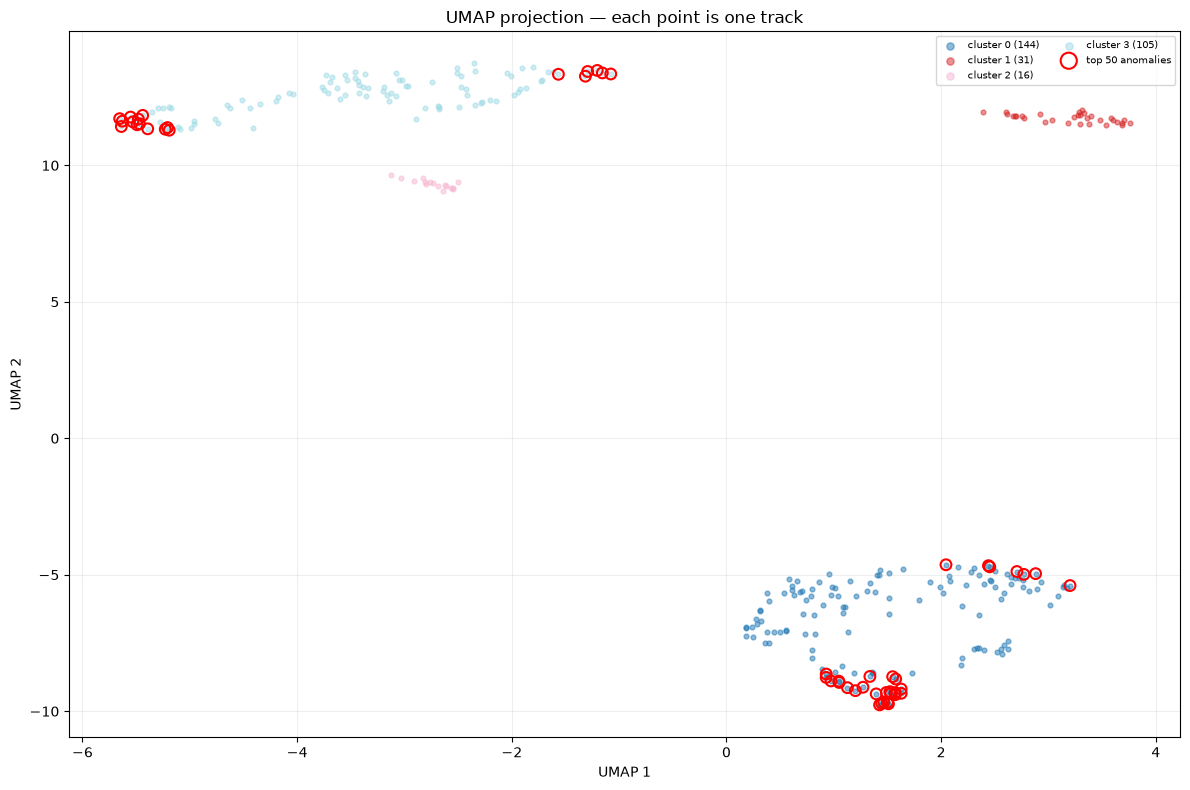

Saved per-video plot: runs_v2\umap_by_video\day_clusters.png
Saved per-video plot: runs_v2\umap_by_video\f_2020-03-16_03-42-13_c_clusters.png
Saved per-video plot: runs_v2\umap_by_video\night_clusters.png
Saved → runs_v2\umap_clusters.png


In [ ]:
# ═══════════════════════════════════════════════════════════
#  Visualise — UMAP cluster plot
# ═══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 8))
unique_labels = sorted(set(labels))
cmap = plt.get_cmap('tab20', max(len(unique_labels), 1))

for lbl in unique_labels:
    mask  = labels == lbl
    color = 'lightgray' if lbl == -1 else cmap(unique_labels.index(lbl))
    name  = 'noise' if lbl == -1 else f'cluster {lbl}'
    ax.scatter(X2[mask,0], X2[mask,1], c=[color], s=12,
               alpha=0.5, label=f'{name} ({mask.sum()})')

# Highlight top anomalies
top_idxs = np.argsort(dists)[-TOP_K_ANOMALIES:]
ax.scatter(X2[top_idxs,0], X2[top_idxs,1],
           s=60, facecolors='none', edgecolors='red', linewidths=1.5,
           label=f'top {TOP_K_ANOMALIES} anomalies', zorder=5)

ax.set_title("UMAP projection — each point is one track", fontsize=12)
ax.legend(loc='upper right', fontsize=7, ncol=2, markerscale=1.5)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "umap_clusters.png", dpi=150, bbox_inches='tight')
plt.show()

# Save a separate UMAP/HDBSCAN plot for every video.
video_plot_dir = OUTPUT_DIR / 'umap_by_video'
video_plot_dir.mkdir(parents=True, exist_ok=True)
for clip_name, result in per_video_results.items():
    clip_X2 = result['X2']
    clip_labels = result['labels']
    clip_dists = result['dists']
    if len(clip_X2) == 0:
        continue

    fig, ax = plt.subplots(figsize=(10, 7))
    clip_unique = sorted(set(clip_labels))
    clip_cmap = plt.get_cmap('tab20', max(len(clip_unique), 1))
    for label in clip_unique:
        mask = clip_labels == label
        color = ('lightgray' if label == -1
                 else clip_cmap(clip_unique.index(label)))
        name = 'noise' if label == -1 else f'cluster {label}'
        ax.scatter(clip_X2[mask, 0], clip_X2[mask, 1], c=[color],
                   s=14, alpha=0.55, label=f'{name} ({mask.sum()})')

    top_count = min(TOP_K_ANOMALIES, len(clip_X2))
    top_indices = np.argsort(clip_dists)[-top_count:]
    ax.scatter(clip_X2[top_indices, 0], clip_X2[top_indices, 1],
               s=60, facecolors='none', edgecolors='red', linewidths=1.5,
               label=f'top {top_count} anomalies', zorder=5)
    ax.set_title(f'Per-video clusters: {clip_name}', fontsize=12)
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
    ax.grid(alpha=0.2)
    ax.legend(loc='best', fontsize=7, ncol=2, markerscale=1.5)
    plt.tight_layout()
    plot_path = video_plot_dir / f'{Path(clip_name).stem}_clusters.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved per-video plot: {plot_path}')
print(f"Saved → {OUTPUT_DIR / 'umap_clusters.png'}")


In [ ]:
# ═══════════════════════════════════════════════════════════
#  Inspect top anomalies from DB
# ═══════════════════════════════════════════════════════════

con = get_db()
top = con.execute("""
    SELECT clip_name, track_id, cluster_label, anomaly_rank,
           duration_frames, mean_speed, linearity, displacement
    FROM   tracks
    ORDER  BY anomaly_rank DESC
    LIMIT  ?
""", (TOP_K_ANOMALIES,)).fetchall()
con.close()

print(f"{'Rank':>4}  {'Clip':<35}  {'TrkID':>6}  {'Cluster':>7}  "
      f"{'AnoScore':>8}  {'Frames':>6}  {'Speed':>6}  {'Linear':>6}")
print("-"*95)
for i,r in enumerate(top,1):
    clip = r['clip_name'][:34]
    print(f"{i:>4}  {clip:<35}  T{r['track_id']:>5}  "
          f"{r['cluster_label']:>7}  {r['anomaly_rank']:>8.3f}  "
          f"{r['duration_frames']:>6}  {r['mean_speed']:>6.2f}  "
          f"{r['linearity']:>6.3f}")


Rank  Clip                                  TrkID  Cluster  AnoScore  Frames   Speed  Linear
-----------------------------------------------------------------------------------------------
   1  day.mkv                              T  401        0     1.000       9   30.92   0.743
   2  day.mkv                              T  322        0     0.987      17   77.31   0.970
   3  day.mkv                              T  398        0     0.983      10   24.56   0.733
   4  day.mkv                              T  387        0     0.970      29   34.34   0.167
   5  day.mkv                              T  397        0     0.969       4   41.29   0.470
   6  day.mkv                              T  437        0     0.878      12  149.40   0.751
   7  day.mkv                              T  409        0     0.870       8  228.47   0.904
   8  day.mkv                              T  368        0     0.867       4  479.10   0.978
   9  day.mkv                              T  408        0     0.86

In [ ]:
# ═══════════════════════════════════════════════════════════
#  Save frames for top anomalous tracks
# ═══════════════════════════════════════════════════════════
#  Reads detections from DB, re-opens video, draws boxes.
#  Only writes frames where a top-ranked track appears.

def save_top_anomaly_frames(n_top: int = TOP_K_ANOMALIES, max_per_track: int = 20):
    con = get_db()
    top_tracks = con.execute("""
        SELECT clip_name, track_id, anomaly_rank, cluster_label
        FROM   tracks ORDER BY anomaly_rank DESC LIMIT ?
    """, (n_top,)).fetchall()

    # Group by clip
    by_clip: Dict[str, List] = {}
    for t in top_tracks:
        by_clip.setdefault(t['clip_name'], []).append(t)

    for clip_name, tracks in by_clip.items():
        vp = VIDEO_DIR / clip_name
        if not vp.exists(): continue

        tids = [t['track_id'] for t in tracks]
        rank_map = {t['track_id']: t['anomaly_rank'] for t in tracks}

        # Load detections for these tracks
        placeholders = ','.join('?'*len(tids))
        dets = con.execute(f"""
            SELECT track_id,frame_idx,x1,y1,x2,y2
            FROM   detections
            WHERE  clip_name=? AND track_id IN ({placeholders})
            ORDER  BY frame_idx
        """, [clip_name]+tids).fetchall()

        by_frame: Dict[int,List] = {}
        for d in dets:
            by_frame.setdefault(d['frame_idx'],[]).append(d)

        cap      = cv2.VideoCapture(str(vp))
        clip_dir = OUTPUT_DIR / "flagged" / Path(clip_name).stem
        clip_dir.mkdir(parents=True, exist_ok=True)
        saved_per_track: Dict[int,int] = {}

        for fi in range(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))):
            ret,frame=cap.read()
            if not ret: break
            if fi not in by_frame: continue
            viz=frame.copy()
            for d in by_frame[fi]:
                tid=d['track_id']
                if saved_per_track.get(tid,0)>=max_per_track: continue
                x1,y1,x2,y2=(int(v) for v in (d['x1'],d['y1'],d['x2'],d['y2']))
                rank=rank_map.get(tid,0)
                # Red for very anomalous, green otherwise
                color=(0,0,220) if rank>0.7 else (0,200,0)
                cv2.rectangle(viz,(x1,y1),(x2,y2),color,2)
                cv2.putText(viz,f"T{tid} r={rank:.2f}",
                            (x1,max(y1-6,14)),cv2.FONT_HERSHEY_SIMPLEX,
                            0.45,color,1,cv2.LINE_AA)
                saved_per_track[tid]=saved_per_track.get(tid,0)+1
            cv2.imwrite(str(clip_dir/f"frame_{fi:06d}.jpg"),viz)

        cap.release()
        n=sum(saved_per_track.values())
        print(f"  {clip_name}: {n} frames saved → {clip_dir}")

    con.close()

save_top_anomaly_frames()


  f_2020-03-16_03-42-13_c.mkv: 80 frames saved → runs_v2\flagged\f_2020-03-16_03-42-13_c


In [ ]:
# ═══════════════════════════════════════════════════════════
#  DB query helpers — run these any time
# ═══════════════════════════════════════════════════════════

def db_summary():
    con = get_db()
    clips  = con.execute("SELECT COUNT(*) FROM clips").fetchone()[0]
    tracks = con.execute("SELECT COUNT(*) FROM tracks").fetchone()[0]
    dets   = con.execute("SELECT COUNT(*) FROM detections").fetchone()[0]
    embs   = con.execute("SELECT COUNT(*) FROM embeddings").fetchone()[0]
    clustered = con.execute(
        "SELECT COUNT(*) FROM tracks WHERE cluster_label > -2").fetchone()[0]
    con.close()
    print(f"DB: {DB_PATH}")
    print(f"  Clips       : {clips}")
    print(f"  Tracks      : {tracks}")
    print(f"  Detections  : {dets}")
    print(f"  Embeddings  : {embs}")
    print(f"  Clustered   : {clustered}")

def get_track(clip_name: str, track_id: int) -> dict:
    """Fetch everything for one track."""
    con = get_db()
    t   = con.execute("SELECT * FROM tracks WHERE clip_name=? AND track_id=?",
                      (clip_name, track_id)).fetchone()
    e   = con.execute("SELECT * FROM embeddings WHERE clip_name=? AND track_id=?",
                      (clip_name, track_id)).fetchone()
    d   = con.execute("SELECT * FROM detections WHERE clip_name=? AND track_id=?",
                      (clip_name, track_id)).fetchall()
    con.close()
    return dict(track=dict(t), embedding=np.frombuffer(e['embedding'],np.float32) if e else None,
                detections=[dict(r) for r in d])

db_summary()


DB: runs_v2\tracks.db
  Clips       : 8
  Tracks      : 21342
  Detections  : 670864
  Embeddings  : 296
  Clustered   : 296


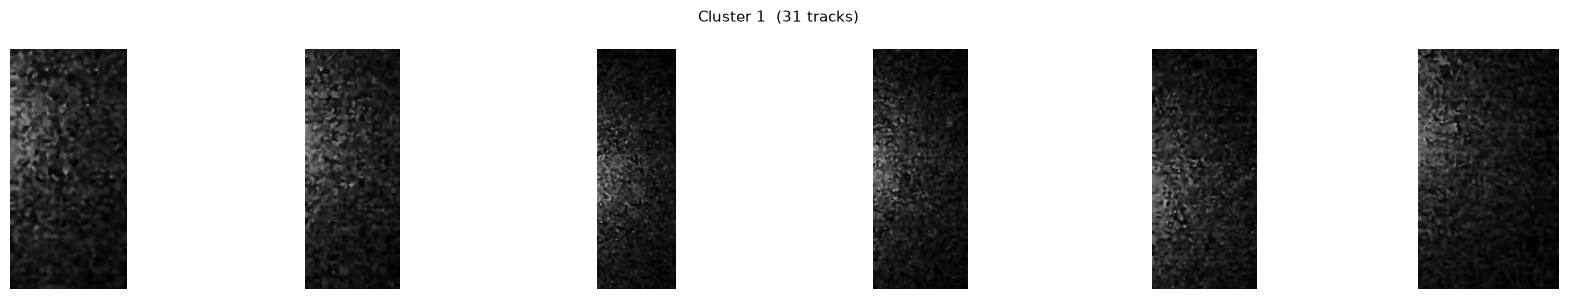

In [ ]:
# ═══════════════════════════════════════════════════════════
#  Visualise — sample crops per cluster
# ═══════════════════════════════════════════════════════════
# Shows a grid of N example crops for each cluster so you can
# see what kind of object each cluster actually contains.

SAMPLES_PER_CLUSTER = 6   # crops to show per cluster

def show_cluster_samples(n_samples: int = SAMPLES_PER_CLUSTER):
    con = get_db()

    unique_labels = sorted(set(labels))

    for lbl in unique_labels:
        # Get track indices belonging to this cluster
        cluster_idxs = np.where(labels == lbl)[0]
        sample_idxs  = cluster_idxs[:n_samples]   # just take first N

        crops = []
        for idx in sample_idxs:
            m         = meta[idx]
            clip_name = m['clip_name']
            track_id  = m['track_id']

            # Get first detection for this track
            det = con.execute("""
                SELECT frame_idx, x1, y1, x2, y2
                FROM   detections
                WHERE  clip_name=? AND track_id=?
                ORDER  BY frame_idx
                LIMIT  1
            """, (clip_name, track_id)).fetchone()
            if det is None:
                continue

            # Read that frame from the video
            vp  = VIDEO_DIR / clip_name
            cap = cv2.VideoCapture(str(vp))
            cap.set(cv2.CAP_PROP_POS_FRAMES, det['frame_idx'])
            ret, frame = cap.read()
            cap.release()
            if not ret:
                continue

            bbox = (det['x1'], det['y1'], det['x2'], det['y2'])
            crop = make_tracking_cutout(frame, bbox)
            if crop is not None:
                crops.append(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))

        if not crops:
            continue

        label_name = f"Cluster {lbl}" if lbl >= 0 else "Noise / outliers"
        n_in_cluster = int((labels == lbl).sum())

        fig, axes = plt.subplots(1, len(crops),
                                  figsize=(3 * len(crops), 3))
        if len(crops) == 1:
            axes = [axes]
        fig.suptitle(f"{label_name}  ({n_in_cluster} tracks)", fontsize=11)

        for ax, crop in zip(axes, crops):
            ax.imshow(crop)
            ax.axis('off')

        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"cluster_{lbl}_samples.png",
                    dpi=120, bbox_inches='tight')
        plt.show()

    con.close()

show_cluster_samples()

In [ ]:
# ============================================================
# Create tracking-overlay videos
# ============================================================

import colorsys
import sqlite3
from collections import defaultdict, deque
from pathlib import Path

import cv2
from tqdm import tqdm

OVERLAY_DIR = OUTPUT_DIR / "overlay_videos"
OVERLAY_DIR.mkdir(parents=True, exist_ok=True)

# False: show every detected/tracked object.
# True: show only noise-cluster or high-anomaly tracks.
OVERLAY_ONLY_ANOMALIES = False
OVERLAY_ANOMALY_THRESHOLD = 0.70

# Set to 0 to disable motion trails.
OVERLAY_TRAIL_FRAMES = 15


def overlay_track_color(track_id):
    """Give every track ID a persistent, unique color."""
    hue = (track_id * 0.618033988749895) % 1.0
    r, g, b = colorsys.hsv_to_rgb(hue, 0.80, 1.0)
    return int(b * 255), int(g * 255), int(r * 255)


def overlay_text(frame, text, position, color, scale=0.55, thickness=1):
    """Draw readable text with a black background."""
    font = cv2.FONT_HERSHEY_SIMPLEX
    (text_width, text_height), baseline = cv2.getTextSize(
        text, font, scale, thickness
    )

    x, y = position
    x = max(0, min(x, frame.shape[1] - text_width - 8))
    y = max(text_height + baseline + 6, y)

    cv2.rectangle(
        frame,
        (x, y - text_height - baseline - 6),
        (x + text_width + 8, y + 3),
        (15, 15, 15),
        cv2.FILLED,
    )

    cv2.putText(
        frame,
        text,
        (x + 4, y - baseline),
        font,
        scale,
        color,
        thickness,
        cv2.LINE_AA,
    )


def load_overlay_detections(video_name):
    """Load detection-backed boxes from the tracking database."""
    con = sqlite3.connect(str(DB_PATH))
    con.row_factory = sqlite3.Row

    rows = con.execute(
        """
        SELECT
            d.frame_idx,
            d.track_id,
            d.x1, d.y1, d.x2, d.y2,
            d.speed,
            t.cluster_label,
            t.anomaly_rank,
            t.video_cluster_label,
            t.video_anomaly_rank
        FROM detections AS d
        JOIN tracks AS t
          ON t.clip_name = d.clip_name
         AND t.track_id = d.track_id
        WHERE d.clip_name = ?
        ORDER BY d.frame_idx, d.track_id
        """,
        (video_name,),
    ).fetchall()

    con.close()

    detections_by_frame = defaultdict(list)
    track_ids = set()

    for row in rows:
        detection = dict(row)

        is_anomaly = (
            detection["cluster_label"] == -1
            or detection["video_cluster_label"] == -1
            or detection["anomaly_rank"] >= OVERLAY_ANOMALY_THRESHOLD
            or detection["video_anomaly_rank"] >= OVERLAY_ANOMALY_THRESHOLD
        )

        if OVERLAY_ONLY_ANOMALIES and not is_anomaly:
            continue

        detections_by_frame[detection["frame_idx"]].append(detection)
        track_ids.add(detection["track_id"])

    return detections_by_frame, track_ids


def create_overlay_video(video_path, trail_frames=OVERLAY_TRAIL_FRAMES):
    detections_by_frame, track_ids = load_overlay_detections(video_path.name)

    if not detections_by_frame:
        print(f"No detections found for {video_path.name}")
        return None

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"Could not open {video_path}")
        return None

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    output_path = (
        OVERLAY_DIR / f"{video_path.stem}_tracking_overlay.mp4"
    )

    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height),
    )

    if not writer.isOpened():
        cap.release()
        raise RuntimeError(f"Could not create {output_path}")

    trails = defaultdict(
        lambda: deque(maxlen=max(1, trail_frames))
    )
    last_seen = {}

    image_scale = max(0.7, min(width, height) / 900.0)
    font_scale = 0.50 * image_scale
    box_thickness = max(2, round(2 * image_scale))
    text_thickness = max(1, round(image_scale))

    pbar = tqdm(
        total=total_frames,
        desc=f"Overlay: {video_path.name}"
    )

    frame_idx = 0

    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                break

            frame_detections = detections_by_frame.get(frame_idx, [])

            for detection in frame_detections:
                track_id = int(detection["track_id"])
                color = overlay_track_color(track_id)

                x1 = max(0, min(width - 1, round(detection["x1"])))
                y1 = max(0, min(height - 1, round(detection["y1"])))
                x2 = max(0, min(width - 1, round(detection["x2"])))
                y2 = max(0, min(height - 1, round(detection["y2"])))

                if x2 <= x1 or y2 <= y1:
                    continue

                # Do not connect a trail across a long tracking gap.
                if frame_idx - last_seen.get(track_id, frame_idx) > 3:
                    trails[track_id].clear()

                center = ((x1 + x2) // 2, (y1 + y2) // 2)
                trails[track_id].append(center)
                last_seen[track_id] = frame_idx

                if trail_frames > 0:
                    points = list(trails[track_id])
                    for point_idx in range(1, len(points)):
                        cv2.line(
                            frame,
                            points[point_idx - 1],
                            points[point_idx],
                            color,
                            1,
                            cv2.LINE_AA,
                        )

                cv2.rectangle(
                    frame,
                    (x1, y1),
                    (x2, y2),
                    color,
                    box_thickness,
                )

                overall_cluster = int(detection["cluster_label"])
                overall_anomaly = float(detection["anomaly_rank"])
                video_cluster = int(detection["video_cluster_label"])
                video_anomaly = float(detection["video_anomaly_rank"])
                speed = float(detection["speed"])

                label = (
                    f"ID {track_id} | "
                    f"G:C{overall_cluster}/A{overall_anomaly:.2f} | "
                    f"V:C{video_cluster}/A{video_anomaly:.2f} | "
                    f"{speed:.1f}px/f"
                )

                label_y = y1 - 5 if y1 > 35 else y2 + 24

                overlay_text(
                    frame,
                    label,
                    (x1, label_y),
                    color,
                    font_scale,
                    text_thickness,
                )

            elapsed_seconds = frame_idx / fps

            hud = (
                f"Frame {frame_idx + 1}/{total_frames} | "
                f"{elapsed_seconds:.2f}s | "
                f"Visible: {len(frame_detections)} | "
                f"Total IDs: {len(track_ids)}"
            )

            overlay_text(
                frame,
                hud,
                (12, 32),
                (255, 255, 255),
                font_scale,
                text_thickness,
            )

            writer.write(frame)
            frame_idx += 1
            pbar.update(1)

    finally:
        pbar.close()
        cap.release()
        writer.release()

    print(f"Saved: {output_path}")
    return output_path


# Create one overlay video for every source video.
overlay_videos = []

video_files = sorted(
    path
    for path in VIDEO_DIR.iterdir()
    if path.suffix.lower() in VIDEO_EXTS
)

for video_path in video_files:
    result = create_overlay_video(video_path)
    if result is not None:
        overlay_videos.append(result)

print(f"\nCreated {len(overlay_videos)} overlay video(s).")

Overlay: f_2020-03-16_03-42-13_c.mkv:  93%|█████████▎| 1651/1777 [00:56<00:04, 29.41it/s]

Saved: runs_v2\overlay_videos\f_2020-03-16_03-42-13_c_tracking_overlay.mp4

Created 1 overlay video(s).
